In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###  LOAD DATA

In [2]:
df=pd.read_csv("online_retail.csv")

###  DATA OVERVIEW

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

#### Data Quality Insights
Missing Customer IDs: (243,007 records)
→ Indicates guest users or untracked customers

Missing Descriptions: 4,382 records
→ Minor issue, can be ignored or cleaned

Dataset size: ~1.06 Million transactions → Large & reliable for analysis

## DATA CLEANING

#### 1. Standardize column names

In [6]:
df.columns=df.columns.str.strip().str.replace(' ','_')
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country'],
      dtype='object')


#### 2. Create cancellation flag 

In [7]:
df["is_cancelled"]=df['Invoice'].astype(str).str.startswith('C')

#### 3. Remove null Customer IDs

In [8]:
df=df[df['Customer_ID'].notna()]

#### 4. Remove invalid values

In [9]:
df = df[df['Price'] > 0]
df = df[df['Quantity'] != 0]

### CANCELLATION ANALYSIS

In [10]:
total_orders = df['Invoice'].nunique()
cancelled_orders = df[df['is_cancelled']]['Invoice'].nunique()

cancellation_rate = (cancelled_orders / total_orders) * 100

print("\nCancellation Rate:", round(cancellation_rate, 2), "%")


Cancellation Rate: 17.61 %


### Insights:
Nearly 1 in 5 orders gets cancelled

##### Possible reasons:
Order errors |
Stock issues | 
Customer returns

##### Business Impact:

Revenue leakage |
Operational inefficiency

In [11]:
df = df[~df['is_cancelled']]

In [12]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,is_cancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False


In [13]:
df['Revenue']=df['Quantity']*df['Price']
df.shape

(805549, 10)

# EDA

### Total revenue, total orders, total unique customers

In [14]:
total_revenue = df['Revenue'].sum()
total_orders = df['Invoice'].nunique()
total_customers = df['Customer_ID'].nunique()

print("\nKEY METRICS")
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)


KEY METRICS
Total Revenue: 17743429.178000003
Total Orders: 36969
Total Customers: 5878


The business shows a strong customer base with repeat purchasing behavior

### Monthly revenue trend 

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
Monthly_Revenue=df.groupby('Month')['Revenue'].sum().reset_index()
Monthly_Revenue


,Month,Revenue
0,2009-12,686654.160
1,2010-01,557319.062
2,2010-02,506371.066
3,2010-03,699608.991
4,2010-04,594609.192
5,2010-05,599985.790
6,2010-06,639066.580
7,2010-07,591636.740
8,2010-08,604242.650
9,2010-09,831615.001


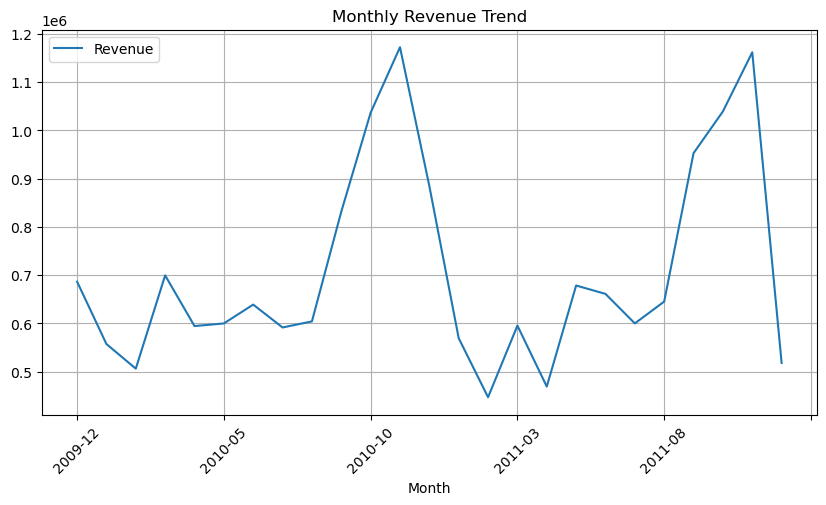

In [16]:
Monthly_Revenue['Month'] = Monthly_Revenue['Month'].astype(str)

Monthly_Revenue.plot(x='Month', y='Revenue', figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.grid()

plt.show()

Peak months: Oct–Nov (both years)
Highest revenue: Nov 2010 (~1.17M) & Nov 2011 (~1.16M)
Drop in early months (Jan–Feb)

##### Insights:

Strong seasonality effect (festive/holiday sales)

Q4 contributes highest revenue

##### Recommendation:

Increase marketing + inventory before festive season

### Top 10 best-selling products by revenue

In [17]:
top_products = df.groupby('Description')['Revenue'].sum() \
                .sort_values(ascending=False).head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                152340.57
JUMBO BAG RED RETROSPOT               136980.08
ASSORTED COLOUR BIRD ORNAMENT         127074.17
POSTAGE                               126563.04
PARTY BUNTING                         103880.23
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79594.33
Name: Revenue, dtype: float64

[]

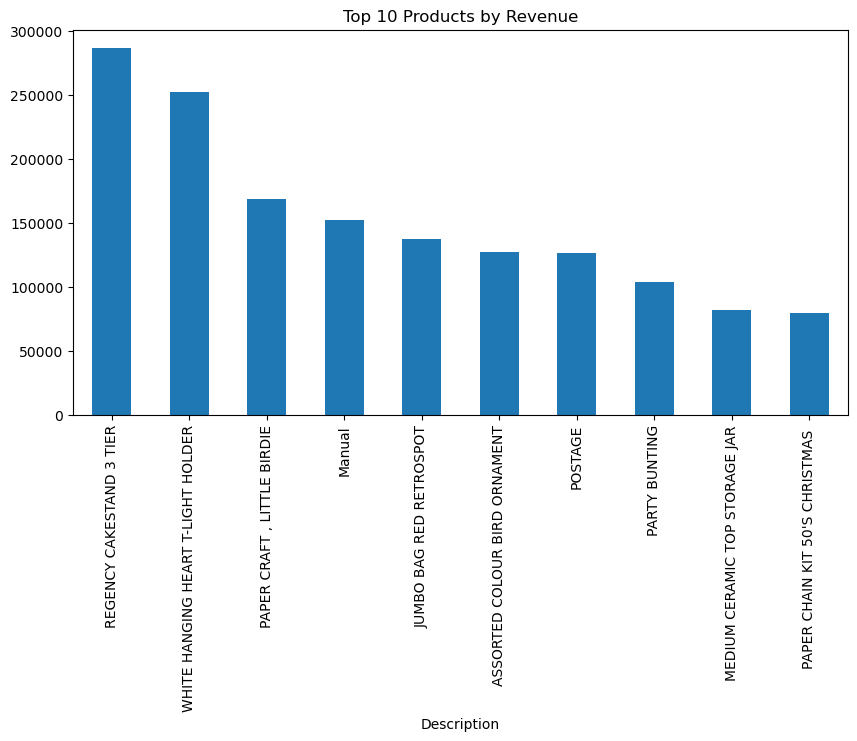

In [18]:
top_products.plot(kind='bar',x='Description',y='Revenue',figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.plot()

#### Top revenue-generating products:

REGENCY CAKESTAND 3 TIER |
WHITE HANGING HEART T-LIGHT HOLDER |
PAPER CRAFT | LITTLE BIRDIE

##### Insights:

Home decor & gift items dominate

Seasonal/occasion-based products sell more

##### Recommendation

Focus on high-margin decor products

Bundle offers for top items

### Top 10 countries by revenue 

In [19]:
top_countries = (df.groupby('Country')['Revenue'].sum() / 1_000_000) \
                 .sort_values(ascending=False).head(10)

top_countries = top_countries.round(2)
print('Revenue of top_countries in million\n',top_countries)

Revenue of top_countries in million
 Country
United Kingdom    14.72
EIRE               0.62
Netherlands        0.55
Germany            0.43
France             0.36
Australia          0.17
Spain              0.11
Switzerland        0.10
Sweden             0.09
Denmark            0.07
Name: Revenue, dtype: float64


[]

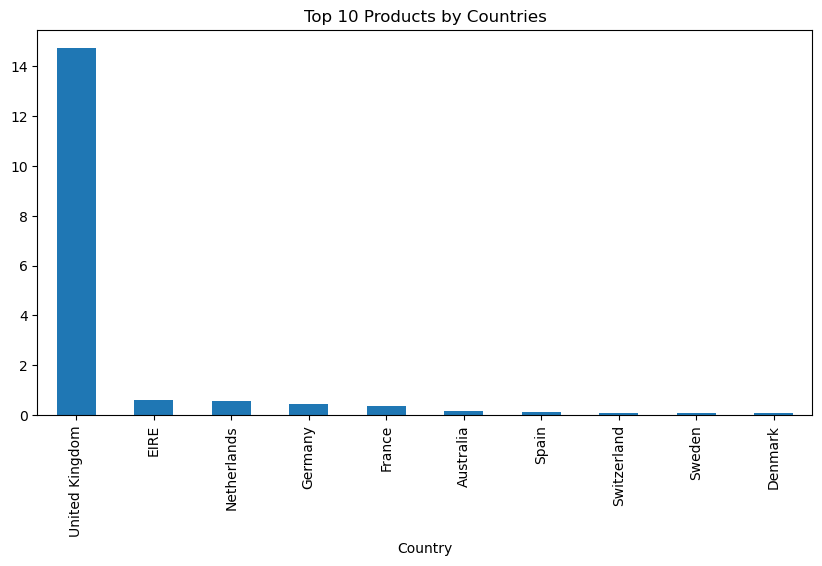

In [20]:
top_countries.plot(kind='bar',x='Country',y='Revenue',figsize=(10,5))
plt.title("Top 10 Products by Countries")
plt.plot()

#### Top revenue contribution:

United Kingdom: ~83%+ of total revenue

Other contributors: EIRE, Netherlands, Germany

##### Insights:

Business is heavily dependent on UK market

Limited international diversification

##### Risk:

Geographic dependency risk

##### Recommendation:

Expand marketing in Europe & other regions



### Average order value per customer

In [21]:
customer_orders = df.groupby(['Customer_ID', 'Invoice'])['Revenue'].sum().reset_index()

average_order_per_customer = customer_orders.groupby('Customer_ID')['Revenue'].mean().reset_index()
average_order_per_customer.rename(columns={'Revenue': 'Avg_Order_Value'}, inplace=True)
average_order_per_customer.head()

,Customer_ID,Avg_Order_Value
0,12346.0,6463.038333
1,12347.0,704.165000
2,12348.0,403.880000
3,12349.0,1107.172500
4,12350.0,334.400000


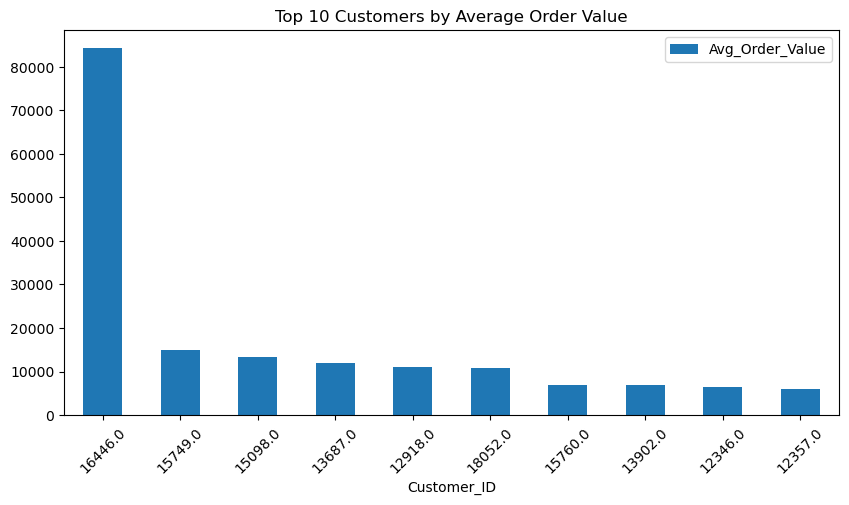

In [22]:
top_aov_customers = average_order_per_customer.sort_values(
    by='Avg_Order_Value', ascending=False
).head(10)
top_aov_customers.plot(kind='bar', x='Customer_ID', y='Avg_Order_Value', figsize=(10,5))

plt.title("Top 10 Customers by Average Order Value")
plt.xticks(rotation=45)
plt.show()

High variation in spending:
Some customers spend ₹6000+ per order
Others spend ₹300–₹700

##### Insights:

Presence of:
High-value customers (VIPs) |
Low-value frequent buyers

### Pareto Analysis

In [23]:
customer_revenue = df.groupby('Customer_ID')['Revenue'].sum().sort_values(ascending=False)

cum_revenue = customer_revenue.cumsum()
total_revenue = customer_revenue.sum()

pareto = (cum_revenue / total_revenue)

top_20_percent_customers = int(0.2 * len(customer_revenue))
top_20_percent_customers

revenue_from_top_20 = pareto.iloc[top_20_percent_customers]

print("Revenue contribution of top 20% customers:", revenue_from_top_20)

Revenue contribution of top 20% customers: 0.7725916970997359


Top 20% customers contribute ~77% of total revenue

##### Classic 80/20 rule (Pareto Principle)

##### Insights:

Small group of customers = major revenue drivers

##### Recommmendations:

Focus on:
Loyalty programs ||
Premium services ||
Personalized offers

# RFM ANALYSIS

### 1. Snapshot date

In [24]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

### 2. RFM calculation

In [25]:
rfm = df.groupby('Customer_ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  
    'Invoice': 'nunique',                                    
    'Revenue': 'sum'                                   
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

### 3. RFM Scoring (1–5 scale)

In [26]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

### 4. Combine RFM score

In [27]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

### CUSTOMER SEGMENTATION

In [28]:
def segment_customer(row):
    if row['R_score'] == 5 and row['F_score'] >= 4:
        return 'Champion'
    elif row['F_score'] >= 4:
        return 'Loyal'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    elif row['R_score'] == 1:
        return 'Lost'
    else:
        return 'New Customer'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

### SEGMENT SUMMARY

In [29]:
segment_summary = rfm.groupby('Segment').agg({
    'Monetary': 'sum',
    'Recency': 'mean',
    'Frequency': 'mean'
}).sort_values(by='Monetary', ascending=False)

print("\n SEGMENT SUMMARY")
print(segment_summary)


 SEGMENT SUMMARY
                 Monetary     Recency  Frequency
Segment                                         
Champion      9124245.705    8.560335  19.339307
Loyal         6016176.167  131.686922   9.309775
New Customer  1744061.904  101.199451   2.329670
At Risk        667121.922  459.281024   1.252791
Lost           191823.480  506.641304   2.929348


Based on your RFM analysis:

### Customer Segments:
##### Champions
→ High value, frequent buyers
##### Loyal Customers
→ Regular buyers
##### At Risk / Lost Customers 
→ Haven’t purchased recently

#### Recommendations
Retarget inactive users
Reward loyal customers
Upsell champions

# EXPORT

In [30]:
rfm.reset_index().to_csv("rfm_table.csv", index=False)

print("\n RFM analysis completed & exported")


 RFM analysis completed & exported


## Summary
-Focus on retaining high-value customers

-Improve operational efficiency (reduce cancellations)

-Leverage seasonality for marketing & inventory

-Expand beyond single geographic market

-Adopt AI-driven analytics for future growth

In [31]:
df.to_csv("retail_sales.csv",index=False)
print("\n retail_sales completed & exported")


 retail_sales completed & exported
